# Clasificación de discurso de odio con BETO (BERT en español)

### Integrantes:
* Camilo Arciniegas
* Deibi Bastidas Cerón

Este notebook retoma lo trabajado en la clase III (clasificación de noticias con un BERT preentrenado) y lo aplica al problema que hemos venido desarrollando en los talleres anteriores: detección de discurso de odio en español:

1. Una LSTM entrenada desde cero (taller 1).
2. Un Transformer implementado desde cero, con el mecanismo de autoatención (taller 2).
3. BETO, un BERT preentrenado sobre un corpus masivo de español.

El objetivo es responder una pregunta: ¿cuánto aporta partir de un modelo preentrenado frente a entrenar arquitecturas equivalentes desde cero con los ~30 000 ejemplos que tenemos disponibles? El taller de Transformers ya dejó una pista relevante: nuestro Transformer desde cero apenas superaba a un MLP simple. La hipótesis de trabajo aquí es que BETO, al haber sido preentrenado sobre un volumen de español muchísimo mayor, debería traducirse en una ventaja.

#### Referencias
- Dataset: https://huggingface.co/datasets/manueltonneau/spanish-hate-speech-superset
- [BETO: Spanish BERT](https://huggingface.co/dccuchile/bert-base-spanish-wwm-cased)
- [BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding](http://arxiv.org/abs/1810.04805)
- Notebook guía del curso: 1-text-classification-with-hf.ipynb

## Planteamiento del problema

En los talleres anteriores discutimos por qué el discurso de odio es difícil de modelar automáticamente: variación dialectal del español entre países, una frontera poco definida entre lenguaje ofensivo y discurso de odio propiamente dicho, y un desbalance de clases considerable. También argumentamos por qué la autoatención es, un mecanismo adecuado para esta tarea. Lo que no habíamos abordado es una limitación práctica de entrenar un Transformer desde cero: nuestro modelo del taller anterior vio apenas ~24 000 ejemplos de entrenamiento, un volumen insuficiente para que una arquitectura de varios millones de parámetros aprenda simultáneamente la estructura del español y la tarea de clasificación. El resultado fue que terminó empatando con un MLP simple.

BETO (dccuchile/bert-base-spanish-wwm-cased) es un BERT preentrenado desde cero sobre un corpus masivo de español (Wikipedia, noticias, subtítulos, entre otros). Al partir de este modelo, se cuenta con una representación razonable de la gramática y la semántica del español antes de ver nuestro dataset. El problema deja de ser "aprender español y detectar odio simultáneamente" para hacer solo lo segundo el cual es un problema de menor escala, que requiere considerablemente menos datos. 

In [1]:
import warnings

warnings.filterwarnings('ignore')

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

In [2]:
!test '{IN_COLAB}' = 'True' && wget  https://github.com/Ohtar10/icesi-nlp/raw/refs/heads/main/requirements.txt && pip install -r requirements.txt
!test '{IN_COLAB}' = 'True' && pip install torchinfo evaluate peft
!test '{IN_COLAB}' = 'True' && pip uninstall -y torchao

--2026-09-26 01:22:46--  https://github.com/Ohtar10/icesi-nlp/raw/refs/heads/main/requirements.txt
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/Ohtar10/icesi-nlp/refs/heads/main/requirements.txt [following]
--2026-09-26 01:22:47--  https://raw.githubusercontent.com/Ohtar10/icesi-nlp/refs/heads/main/requirements.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 979 [text/plain]
Saving to: ‘requirements.txt’

requirements.txt    100%[===================>]     979  --.-KB/s    in 0s      

2026-09-26 01:22:47 (50.8 MB/s) - ‘requirements.txt’ saved [979/979]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━

## Reproducibilidad

Fijamos la semilla de reproducibilidad desde el inicio del notebook

In [3]:
import random
import numpy as np
import torch

SEED = 42

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
print(f"Semilla fijada: {SEED}")

Semilla fijada: 42


### Cargando el dataset

Se intenta cargar el dataset desde el Hub, y si la carga falla se recurre a un CSV local. La columna de etiqueta es labels (0.0 = no odio, 1.0 = odio).

In [4]:
from datasets import load_dataset
import warnings
import os

warnings.filterwarnings("ignore")
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

try:
    dataset = load_dataset('manueltonneau/spanish-hate-speech-superset', split='train')
except Exception as e:
    print(f"No se pudo cargar desde el Hub ({e}); usando el CSV local.")
    dataset = load_dataset('csv', data_files='/content/sample_data/es_hf_102024.csv', split='train')

dataset

README.md:   0%|          | 0.00/6.86k [00:00<?, ?B/s]

No se pudo cargar desde el Hub (Dataset 'manueltonneau/spanish-hate-speech-superset' is a gated dataset on the Hub. You must be authenticated to access it.); usando el CSV local.


Generating train split: 0 examples [00:00, ? examples/s]

Dataset({
    features: ['text', 'labels', 'source', 'dataset', 'nb_annotators', 'tweet_id', 'post_author_country_location'],
    num_rows: 29855
})

In [5]:
dataset[1]

{'text': '@USER @USER @USER Me carga en lo q se convirtió la 2da vuelta a la gobernación...una flaiterío.',
 'labels': 0.0,
 'source': 'Twitter',
 'dataset': 'chileno',
 'nb_annotators': 3,
 'tweet_id': 1402708213246697482,
 'post_author_country_location': 'Chile'}

## Análisis exploratorio de datos (EDA)

Caracterizamos el dataset: balance de clases, distribución de longitud de los textos, y qué vocabulario distingue a cada clase. Cada uno de estos hallazgos informa una decisión posterior (longitud de secuencia, manejo del desbalance, interpretación del análisis de errores).

In [6]:
from collections import Counter

label_counts = Counter(dataset['labels'])
total = sum(label_counts.values())
for label, count in sorted(label_counts.items()):
    print(f"Clase {label}: {count} ejemplos ({count/total:.1%})")

Clase 0.0: 22590 ejemplos (75.7%)
Clase 1.0: 7265 ejemplos (24.3%)


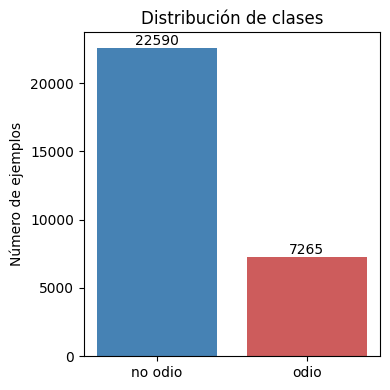

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(4, 4))
labels_plot = ['no odio', 'odio']
counts_plot = [label_counts[0.0], label_counts[1.0]]
ax.bar(labels_plot, counts_plot, color=['steelblue', 'indianred'])
ax.set_ylabel('Número de ejemplos')
ax.set_title('Distribución de clases')
for i, v in enumerate(counts_plot):
    ax.text(i, v + 200, str(v), ha='center')
plt.tight_layout()
plt.show()

In [8]:
text_lengths = [len(row['text']) for row in dataset]
print(f"Texto más corto: {min(text_lengths)}")
print(f"Texto más largo: {max(text_lengths)}")
print(f"Longitud promedio: {sum(text_lengths) / len(text_lengths):.1f}")

Texto más corto: 6
Texto más largo: 559
Longitud promedio: 129.3


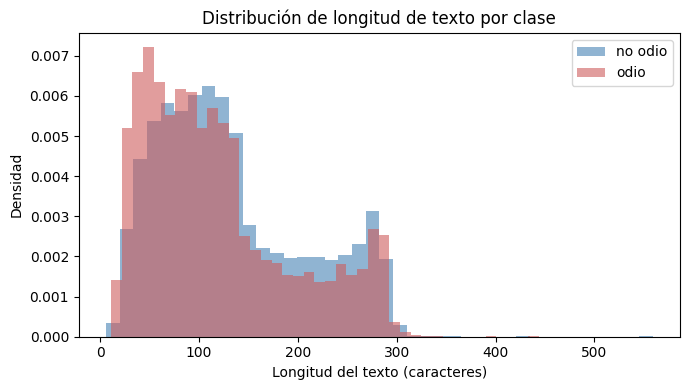

In [9]:
import matplotlib.pyplot as plt

lengths_odio = [len(t) for t, l in zip(dataset['text'], dataset['labels']) if l == 1.0]
lengths_no_odio = [len(t) for t, l in zip(dataset['text'], dataset['labels']) if l == 0.0]

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(lengths_no_odio, bins=40, alpha=0.6, label='no odio', color='steelblue', density=True)
ax.hist(lengths_odio, bins=40, alpha=0.6, label='odio', color='indianred', density=True)
ax.set_xlabel('Longitud del texto (caracteres)')
ax.set_ylabel('Densidad')
ax.set_title('Distribución de longitud de texto por clase')
ax.legend()
plt.tight_layout()
plt.show()

### Composición por sub-fuente

El dataset agrega varios corpus, cada uno anotado en un estudio independiente (columna dataset). Si la proporción de "odio" difiere sustancialmente entre sub-fuentes, es adecuado sospechar que no todas siguieron el mismo criterio de anotación, un punto que retomamos en el análisis de errores del modelo final.

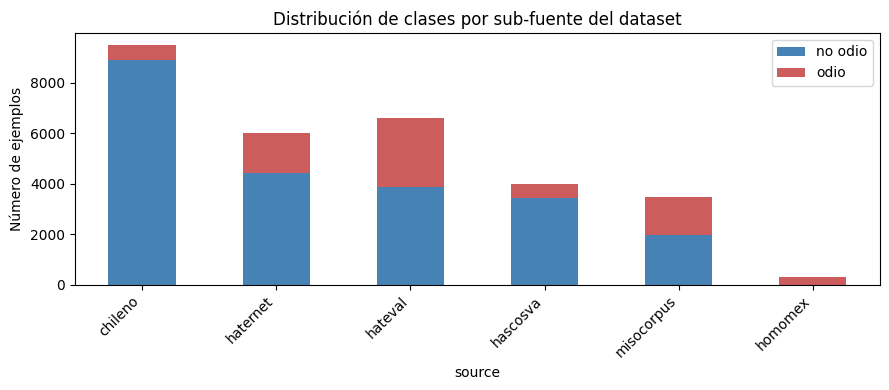

Proporción de 'odio' por sub-fuente:
source
homomex      100.0%
misocorpus    43.5%
hateval       41.5%
haternet      26.1%
hascosva      13.9%
chileno        6.3%


In [10]:
import pandas as pd
import matplotlib.pyplot as plt

source_df = pd.DataFrame({'source': dataset['dataset'], 'label': dataset['labels']})
source_counts = source_df.groupby(['source', 'label']).size().unstack(fill_value=0)
source_counts.columns = ['no odio', 'odio']
source_counts = source_counts.sort_values('no odio', ascending=False)

ax = source_counts.plot(kind='bar', stacked=True, figsize=(9, 4), color=['steelblue', 'indianred'])
ax.set_ylabel('Número de ejemplos')
ax.set_title('Distribución de clases por sub-fuente del dataset')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

prop_odio = (source_counts['odio'] / source_counts.sum(axis=1)).sort_values(ascending=False)
print("Proporción de 'odio' por sub-fuente:")
print(prop_odio.to_string(float_format=lambda x: f'{x:.1%}'))

### Procedencia geográfica y anotación

También revisamos la distribución geográfica de los textos y el número de anotadores por ejemplo (un mayor número de anotadores suele asociarse con una etiqueta más confiable, al reducir el peso del criterio individual de una sola persona).

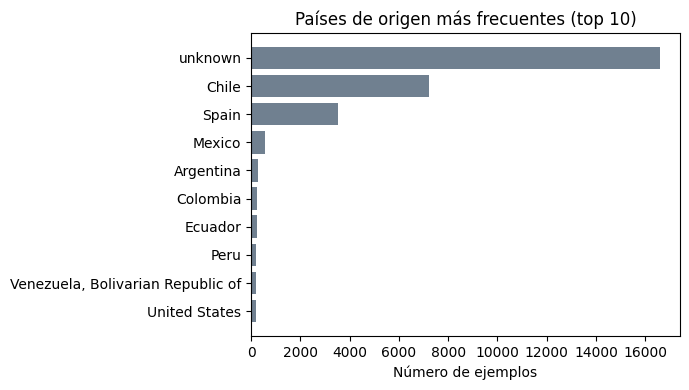

Distribución del número de anotadores por ejemplo:
  3 anotador(es): 23552 ejemplos (78.9%)
  4 anotador(es): 6303 ejemplos (21.1%)


In [11]:
import matplotlib.pyplot as plt
from collections import Counter

country_counts = Counter(c for c in dataset['post_author_country_location'] if c)
top_countries = country_counts.most_common(10)

fig, ax = plt.subplots(figsize=(7, 4))
countries, counts = zip(*top_countries)
ax.barh(countries[::-1], counts[::-1], color='slategray')
ax.set_xlabel('Número de ejemplos')
ax.set_title('Países de origen más frecuentes (top 10)')
plt.tight_layout()
plt.show()

annot_counts = Counter(dataset['nb_annotators'])
print("Distribución del número de anotadores por ejemplo:")
for n, c in sorted(annot_counts.items()):
    print(f"  {n} anotador(es): {c} ejemplos ({c/len(dataset):.1%})")

### Tokenización liviana para el EDA

Para el análisis de vocabulario por clase se segmentará el texto en palabras; no es necesario construir un vocabulario formal. A diferencia de los talleres de LSTM y Transformer, aquí no entrenamos ningún embedding propio, el modelo utiliza el tokenizador y el vocabulario de BETO, que se cargan más adelante. Esta función cumple un propósito exclusivamente exploratorio.

In [12]:
import re

def simple_tokenizer(text):
    text = text.lower()
    text = re.sub(r"[^a-záéíóúüñ]+", " ", text)
    return text.strip().split()

### Vocabulario asociado a cada clase

Además de la proporción de ejemplos por clase, es informativo observar qué palabras están sobrerrepresentadas en "odio" frente a "no odio". Si ese vocabulario corresponde mayoritariamente a insultos y términos discriminatorios explícitos, es razonable esperar que una fracción del problema sea resoluble con señales puramente léxicas.

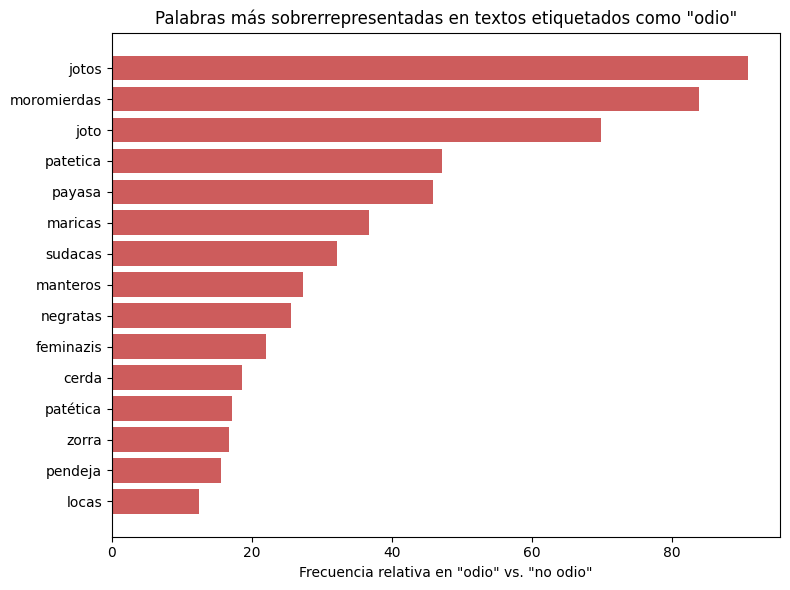

In [13]:
from collections import Counter
import matplotlib.pyplot as plt

STOPWORDS_ES = set("a al algo algunas algunos ante antes como con contra cual cuando de del desde donde durante e el ella ellas ellos en entre era erais eramos eran eras eres es esa esas ese eso esos esta estas este esto estos fue fueron fui fuimos ha habia habla han has hasta hay la las le les lo los mas me mi mientras muy nada ni no nos nosotros o os otro otra para pero poco por porque que quien se sin sobre solo su sus te tiene tu tus un una uno unos usted ustedes y ya yo user".split())

def class_word_counts(target_label):
    counts = Counter()
    for text, label in zip(dataset['text'], dataset['labels']):
        if label == target_label:
            counts.update(w for w in simple_tokenizer(text) if w not in STOPWORDS_ES and len(w) > 2)
    return counts

odio_counts = class_word_counts(1.0)
no_odio_counts = class_word_counts(0.0)
n_odio = sum(odio_counts.values())
n_no_odio = sum(no_odio_counts.values())

MIN_COUNT = 20
ratios = {}
for word, c in odio_counts.items():
    if c >= MIN_COUNT:
        freq_odio = c / n_odio
        freq_no_odio = (no_odio_counts.get(word, 0) + 1) / n_no_odio
        ratios[word] = freq_odio / freq_no_odio

top_words = sorted(ratios.items(), key=lambda kv: -kv[1])[:15]

fig, ax = plt.subplots(figsize=(8, 6))
words, vals = zip(*top_words[::-1])
ax.barh(words, vals, color='indianred')
ax.set_xlabel('Frecuencia relativa en "odio" vs. "no odio"')
ax.set_title('Palabras más sobrerrepresentadas en textos etiquetados como "odio"')
plt.tight_layout()
plt.show()

### Qué nos dice el EDA

- El desbalance de clases (76/24 aprox) implica que el accuracy  es una métrica insuficiente; por eso se utilizará también ROC-AUC y PR-AUC, que no dependen de un umbral de decisión fijo.
- La proporción de "odio" varía apreciablemente entre sub-fuentes, lo que sugiere criterios de anotación heterogéneos. Por esta razón, desglosamos el error del modelo final por sub-fuente en lugar de reportar un único agregado.
- La brevedad de los textos justifica una longitud de secuencia de 64 tokens. Esta decisión es aún más relevante en este notebook que en los anteriores, dado que BETO admite secuencias de hasta 512 tokens por defecto, y el costo computacional de la atención escala de forma cuadrática con la longitud de secuencia.
- Existen palabras claramente sobrerrepresentadas en la clase "odio" (léxico ofensivo y discriminatorio explícito), lo que sugiere que una parte del problema es capturable mediante señales léxicas simples.

## Cargando BETO y su tokenizador

A diferencia de los dos talleres anteriores, no construimos un tokenizador propio: utilizamos el que viene con BETO, entrenado conjuntamente con el modelo sobre su corpus de preentrenamiento. 

In [14]:
from transformers import AutoTokenizer

model_ckpt = "dccuchile/bert-base-spanish-wwm-cased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

print(f"Vocabulario de BETO: {tokenizer.vocab_size} tokens")
print(f"Longitud máxima de secuencia soportada: {tokenizer.model_max_length}")
print()
print(tokenizer("odio a la gente!", max_length=10, truncation=True, padding='max_length'))

config.json:   0%|          | 0.00/648 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/364 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/242k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/480k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

Vocabulario de BETO: 31002 tokens
Longitud máxima de secuencia soportada: 512

{'input_ids': [4, 7192, 1013, 1030, 2114, 1127, 5, 1, 1, 1], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 0, 0, 0]}


El vocabulariol de BETO tiene aproximadamente 31 000 tokens, pero fue entrenado sobre un corpus de español. La diferencia entre vocabularios que se rrealizaron en los anteriores talleres no reside tanto en el tamaño del vocabulario como en la cantidad de ejemplos de cada palabra que el modelo observó durante el preentrenamiento — que es precisamente la limitación que un modelo preentrenado permite superar.

## Preparando los datos para el Trainer de Hugging Face

Definimos las etiquetas legibles (id2label/label2id), particionamos el dataset con la misma proporción 80/10/10 utilizada en los talleres anteriores y tokenizamos con el tokenizador de BETO. Usamos max_length=64, justificado por el EDA que está considerablemente por debajo del límite de 512 tokens de BETO, pensado originalmente para documentos más extensos que un tweet.

In [15]:
import numpy as np
from datasets.dataset_dict import DatasetDict

id2label = {0: 'no odio', 1: 'odio'}
label2id = {'no odio': 0, 'odio': 1}
raw_label_map = dict(enumerate(np.unique(dataset['labels'])))
raw_label_map = {v: k for k, v in raw_label_map.items()}  # {0.0: 0, 1.0: 1}

MAX_LEN = 64  # justificado por el EDA de longitud de texto (tweets, no artículos)

training_split = dataset.train_test_split(train_size=0.8, seed=SEED)
validation_split = training_split['test'].train_test_split(train_size=0.5, seed=SEED)

split_dataset = DatasetDict({
    'train': training_split['train'],
    'val': validation_split['train'],
    'test': validation_split['test'],
})
split_dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'source', 'dataset', 'nb_annotators', 'tweet_id', 'post_author_country_location'],
        num_rows: 23884
    })
    val: Dataset({
        features: ['text', 'labels', 'source', 'dataset', 'nb_annotators', 'tweet_id', 'post_author_country_location'],
        num_rows: 2985
    })
    test: Dataset({
        features: ['text', 'labels', 'source', 'dataset', 'nb_annotators', 'tweet_id', 'post_author_country_location'],
        num_rows: 2986
    })
})

In [16]:
def preprocess_function(examples):
    tokenized = tokenizer(examples['text'], max_length=MAX_LEN, truncation=True, padding='max_length')
    tokenized['label'] = [raw_label_map[l] for l in examples['labels']]
    return tokenized

tokenized_dataset = split_dataset.map(preprocess_function, batched=True)
tokenized_dataset

Map:   0%|          | 0/23884 [00:00<?, ? examples/s]

Map:   0%|          | 0/2985 [00:00<?, ? examples/s]

Map:   0%|          | 0/2986 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'source', 'dataset', 'nb_annotators', 'tweet_id', 'post_author_country_location', 'input_ids', 'token_type_ids', 'attention_mask', 'label'],
        num_rows: 23884
    })
    val: Dataset({
        features: ['text', 'labels', 'source', 'dataset', 'nb_annotators', 'tweet_id', 'post_author_country_location', 'input_ids', 'token_type_ids', 'attention_mask', 'label'],
        num_rows: 2985
    })
    test: Dataset({
        features: ['text', 'labels', 'source', 'dataset', 'nb_annotators', 'tweet_id', 'post_author_country_location', 'input_ids', 'token_type_ids', 'attention_mask', 'label'],
        num_rows: 2986
    })
})

## Métricas y manejo del desbalance de clases

Para accuracy utilizamos la librería "evaluate", como en el notebook guía, complementada con precisión, recall y F1 macro calculados con sklearn. Igual que en los talleres anteriores, dado el desbalance de clases. El ROC-AUC y el PR-AUC (métricas independientes del umbral de decisión) se calculan aparte, una vez concluido el entrenamiento, porque requieren las probabilidades completas y no solo la predicción final (argmax) que produce "compute_metrics" en cada época.

Para el manejo del desbalance optamos por una función de pérdida ponderada por clase, en lugar de un "WeightedRandomSampler" como en el taller de la LSTM, implementada mediante un Trainer propio (WeightedTrainer). Un modelo preentrenado como BETO parte de una representación del lenguaje considerablemente más robusta que una LSTM entrenada desde cero, por lo que resulta menos susceptible a colapsar hacia la clase mayoritaria. Aunque el desbalance sigue siendo un factor a controlar.

In [17]:
import evaluate
from sklearn.metrics import precision_recall_fscore_support

accuracy_metric = evaluate.load("accuracy")

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_metric.compute(predictions=preds, references=labels)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='macro', zero_division=0)
    return {**acc, 'f1_macro': f1, 'precision_macro': precision, 'recall_macro': recall}

In [18]:
import torch
from transformers import Trainer

class WeightedTrainer(Trainer):
    """Un Trainer estándar de Hugging Face, con la pérdida ponderada por
    clase -- el mismo principio de class_weight/sampler aplicado en los
    talleres anteriores, adaptado a esta API."""

    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        weight = self.class_weights.to(logits.device) if self.class_weights is not None else None
        loss = torch.nn.functional.cross_entropy(logits, labels, weight=weight)
        return (loss, outputs) if return_outputs else loss


train_label_ids = tokenized_dataset['train']['label']
class_counts = torch.bincount(torch.tensor(train_label_ids))
class_weights = 1.0 / torch.sqrt(class_counts.float())  # corrección parcial, mismo criterio que en los talleres anteriores
print(f"Conteo por clase en train: {class_counts.tolist()}")
print(f"Pesos de clase: {class_weights.tolist()}")

Conteo por clase en train: [18082, 5802]
Pesos de clase: [0.007436640094965696, 0.013128380291163921]


In [19]:
from transformers import TrainingArguments

batch_size = 32 if IN_COLAB else 8
logging_steps = max(len(tokenized_dataset['train']) // batch_size, 1)

training_args = TrainingArguments(
    output_dir='./hf-hate-speech',
    num_train_epochs=2,
    learning_rate=2e-5,
    per_device_eval_batch_size=batch_size,
    per_device_train_batch_size=batch_size,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    disable_tqdm=False,
    logging_steps=logging_steps,
    report_to='tensorboard',
    seed=SEED,
)

In [20]:
from sklearn.metrics import roc_auc_score, average_precision_score

def evaluate_probs(trainer, split):
    """Ejecuta predict() sobre un split y calcula ROC-AUC/PR-AUC a partir
    de las probabilidades -- complementa a compute_metrics, que solo
    expone la predicción final (argmax), no la distribución completa."""
    raw = trainer.predict(tokenized_dataset[split])
    logits = torch.tensor(raw.predictions)
    probs_odio = torch.softmax(logits, dim=1)[:, 1].numpy()
    true = raw.label_ids
    return {
        'roc_auc': roc_auc_score(true, probs_odio),
        'pr_auc': average_precision_score(true, probs_odio),
        'probs': probs_odio,
        'true': true,
    }

## Etapa 1: Backbone congelado, cabezal por defecto

Cargamos BETO, congelamos la totalidad de los parámetros del modelo base y dejamos entrenable únicamente el cabezal de clasificación por defecto (una capa lineal). Esto equivale, en términos prácticos, a usar BETO como extractor de características fijo.

In [21]:
from transformers import AutoModelForSequenceClassification

model_stage1 = AutoModelForSequenceClassification.from_pretrained(
    model_ckpt, num_labels=2, id2label=id2label, label2id=label2id
)
for param in model_stage1.base_model.parameters():
    param.requires_grad = False

trainer_stage1 = WeightedTrainer(
    model=model_stage1,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['val'],
    processing_class=tokenizer,
    class_weights=class_weights,
)
trainer_stage1.train()

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  440MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
1,0.639326,0.626891,0.760804,0.432078,0.380402,0.500000
2,0.628106,0.621680,0.761474,0.436395,0.755745,0.501881


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1494, training_loss=0.6337516753070326, metrics={'train_runtime': 237.9168, 'train_samples_per_second': 200.776, 'train_steps_per_second': 6.28, 'total_flos': 1571036111554560.0, 'train_loss': 0.6337516753070326, 'epoch': 2.0})

In [22]:
stage1_results = evaluate_probs(trainer_stage1, 'val')
print(f"Etapa 1 (congelado + cabezal por defecto): ROC-AUC(val)={stage1_results['roc_auc']:.3f}  "
      f"PR-AUC(val)={stage1_results['pr_auc']:.3f}")

Etapa 1 (congelado + cabezal por defecto): ROC-AUC(val)=0.672  PR-AUC(val)=0.417


## Etapa 2: Backbone congelado, cabezal propio

Sustituimos el cabezal por defecto (una única capa lineal) por una red densa de mayor capacidad, manteniendo el backbone de BETO congelado. La hipótesis es que un cabezal con mayor capacidad debería aprovechar mejor las representaciones congeladas de BETO.

In [23]:
import torch.nn as nn

model_stage2 = AutoModelForSequenceClassification.from_pretrained(
    model_ckpt, num_labels=2, id2label=id2label, label2id=label2id
)
for param in model_stage2.base_model.parameters():
    param.requires_grad = False

model_stage2.classifier = nn.Sequential(
    nn.Linear(768, 512),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(256, 2),
)

trainer_stage2 = WeightedTrainer(
    model=model_stage2,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['val'],
    processing_class=tokenizer,
    class_weights=class_weights,
)
trainer_stage2.train()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
1,0.634079,0.595522,0.780235,0.588696,0.708731,0.582866
2,0.603074,0.580390,0.777889,0.642727,0.686957,0.627896


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1494, training_loss=0.6186201877223759, metrics={'train_runtime': 238.7853, 'train_samples_per_second': 200.046, 'train_steps_per_second': 6.257, 'total_flos': 1580648384415744.0, 'train_loss': 0.6186201877223759, 'epoch': 2.0})

In [24]:
stage2_results = evaluate_probs(trainer_stage2, 'val')
print(f"Etapa 2 (congelado + cabezal propio): ROC-AUC(val)={stage2_results['roc_auc']:.3f}  "
      f"PR-AUC(val)={stage2_results['pr_auc']:.3f}")

Etapa 2 (congelado + cabezal propio): ROC-AUC(val)=0.728  PR-AUC(val)=0.482


## Etapa 3: Fine-tuning completo

En esta etapa, todas las capas de BETO quedan libres para entrenarse, con el cabezal por defecto. Es la etapa computacionalmente más costosa, pero también la que obtuvo el mejor resultado por un margen considerable en el notebook guía.

In [25]:
model_stage3 = AutoModelForSequenceClassification.from_pretrained(
    model_ckpt, num_labels=2, id2label=id2label, label2id=label2id
)

trainer_stage3 = WeightedTrainer(
    model=model_stage3,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['val'],
    processing_class=tokenizer,
    class_weights=class_weights,
)
trainer_stage3.train()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
1,0.439683,0.364448,0.861642,0.807789,0.811385,0.804406
2,0.282140,0.379454,0.855611,0.810857,0.798759,0.826849


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1494, training_loss=0.36071520549066893, metrics={'train_runtime': 604.0525, 'train_samples_per_second': 79.079, 'train_steps_per_second': 2.473, 'total_flos': 1571036111554560.0, 'train_loss': 0.36071520549066893, 'epoch': 2.0})

In [26]:
stage3_results = evaluate_probs(trainer_stage3, 'val')
print(f"Etapa 3 (fine tuning completo): ROC-AUC(val)={stage3_results['roc_auc']:.3f}  "
      f"PR-AUC(val)={stage3_results['pr_auc']:.3f}")

Etapa 3 (fine tuning completo): ROC-AUC(val)=0.907  PR-AUC(val)=0.791


## Etapa 4: Fine-tuning eficiente con LoRA

LoRA (Low-Rank Adaptation) constituye un punto intermedio. Reduce drásticamente los costos de entrenamiento al mantener congeladas las matrices originales del modelo e introducir dos pequeñas matrices de bajo rango ($A$ y $B$), logrando que menos del 1% de los parámetros totales sean entrenables. Esto permite retener la flexibilidad en cada capa de atención y recuperar casi todo el rendimiento del fine-tuning completo a una fracción mínima del costo computacional.

In [27]:
from peft import LoraConfig, get_peft_model, TaskType

model_stage4_base = AutoModelForSequenceClassification.from_pretrained(
    model_ckpt, num_labels=2, id2label=id2label, label2id=label2id
)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,                                    # rango de la actualización de bajo rango: a mayor r, mayor capacidad y más parámetros
    lora_alpha=16,                          # factor de escala de la actualización LoRA; la convención habitual es usar 2x el rango
    lora_dropout=0.1,
    target_modules=["query", "value"],      # LoRA se restringe a las proyecciones de atención, no se aplica al resto de la red
)

model_stage4 = get_peft_model(model_stage4_base, lora_config)
# fracción de parámetros entrenables respecto al total del modelo -- referencia directa contra la Etapa 3
model_stage4.print_trainable_parameters()

trainer_stage4 = WeightedTrainer(
    model=model_stage4,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['val'],
    processing_class=tokenizer,
    class_weights=class_weights,
)
trainer_stage4.train()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	

trainable params: 296,450 || all params: 110,148,868 || trainable%: 0.2691


[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
1,0.624335,0.571328,0.783585,0.642548,0.699843,0.626358
2,0.574550,0.549138,0.764824,0.659713,0.670199,0.652437


TrainOutput(global_step=1494, training_loss=0.5994912141776947, metrics={'train_runtime': 435.5235, 'train_samples_per_second': 109.679, 'train_steps_per_second': 3.43, 'total_flos': 1576473867816960.0, 'train_loss': 0.5994912141776947, 'epoch': 2.0})

In [28]:
stage4_results = evaluate_probs(trainer_stage4, 'val')
print(f"Etapa 4 (LoRA): ROC-AUC(val)={stage4_results['roc_auc']:.3f}  "
      f"PR-AUC(val)={stage4_results['pr_auc']:.3f}")

Etapa 4 (LoRA): ROC-AUC(val)=0.760  PR-AUC(val)=0.513


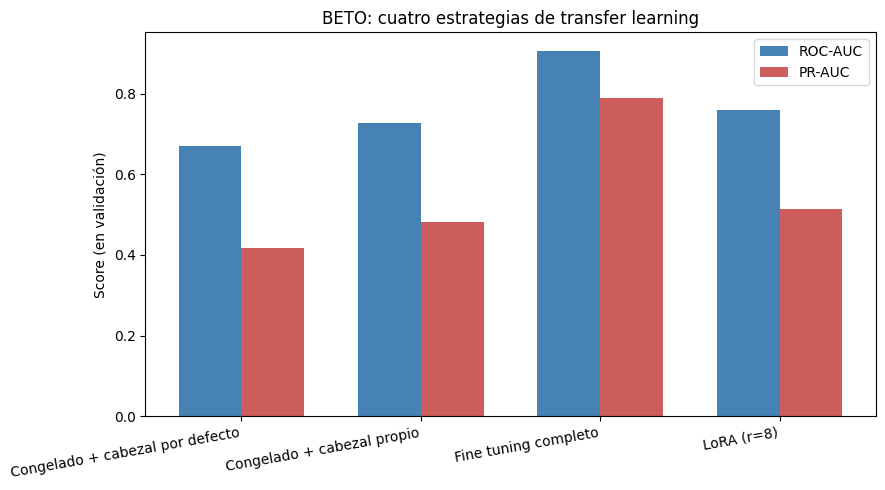

,ROC-AUC,PR-AUC
Congelado + cabezal por defecto,0.671602,0.416574
Congelado + cabezal propio,0.727874,0.482286
Fine tuning completo,0.907235,0.790507
LoRA (r=8),0.760412,0.513416


In [29]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

stage_names = ['Congelado + cabezal por defecto', 'Congelado + cabezal propio', 'Fine tuning completo', 'LoRA (r=8)']
stage_results = [stage1_results, stage2_results, stage3_results, stage4_results]
roc_aucs = [r['roc_auc'] for r in stage_results]
pr_aucs = [r['pr_auc'] for r in stage_results]

x = np.arange(len(stage_names))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, roc_aucs, width, label='ROC-AUC', color='steelblue')
ax.bar(x + width/2, pr_aucs, width, label='PR-AUC', color='indianred')
ax.set_xticks(x); ax.set_xticklabels(stage_names, rotation=10, ha='right')
ax.set_ylabel('Score (en validación)')
ax.set_title('BETO: cuatro estrategias de transfer learning')
ax.legend()
plt.tight_layout()
plt.show()

pd.DataFrame({'ROC-AUC': roc_aucs, 'PR-AUC': pr_aucs}, index=stage_names)

### Lo que encontramos con las cuatro etapas

Resultados en validación:

| Etapa | ROC-AUC | PR-AUC | % parámetros entrenables |
|---|---|---|---|
| Congelado + cabezal por defecto | 0.672 | 0.417 | — |
| Congelado + cabezal propio | 0.728 | 0.482 | — |
| Fine-tuning completo | 0.907 | 0.791 | 100% |
| LoRA (r=8) | 0.760 | 0.513 | 0.27% |

La Etapa 3 (fine-tuning completo) sigue superando por mucho a las demás (ROC-AUC de 0.907 vs 0.728 en la Etapa 2), demostrando que un backbone congelado no basta para este problema.

El resultado de LoRA: Con solo 0.27% de parámetros entrenables, LoRA ($r=8$) logra una mejora modesta (0.760 ROC-AUC), quedando muy cerca del backbone congelado y lejos del fine-tuning completo.

Conclusión y balance: La actualización de bajo rango se quedó corta para la complejidad del problema. Aunque aumentar el rango o los módulos objetivo podría cerrar la brecha, esto también reduciría la ventaja de eficiencia de LoRA.

## Comparación completa: LSTM, Transformer desde cero y BETO

En este punto, se comparan el mejor modelo de cada enfoque, entrenados y evaluados sobre el mismo dataset (aunque no exactamente la misma partición aleatoria en los dos primeros talleres, dado que la semilla se fijó recién a partir del taller de Transformers). Los valores de la LSTM y el Transformer corresponden a los resultados ya documentados en esos notebooks; los de BETO son los de este taller.

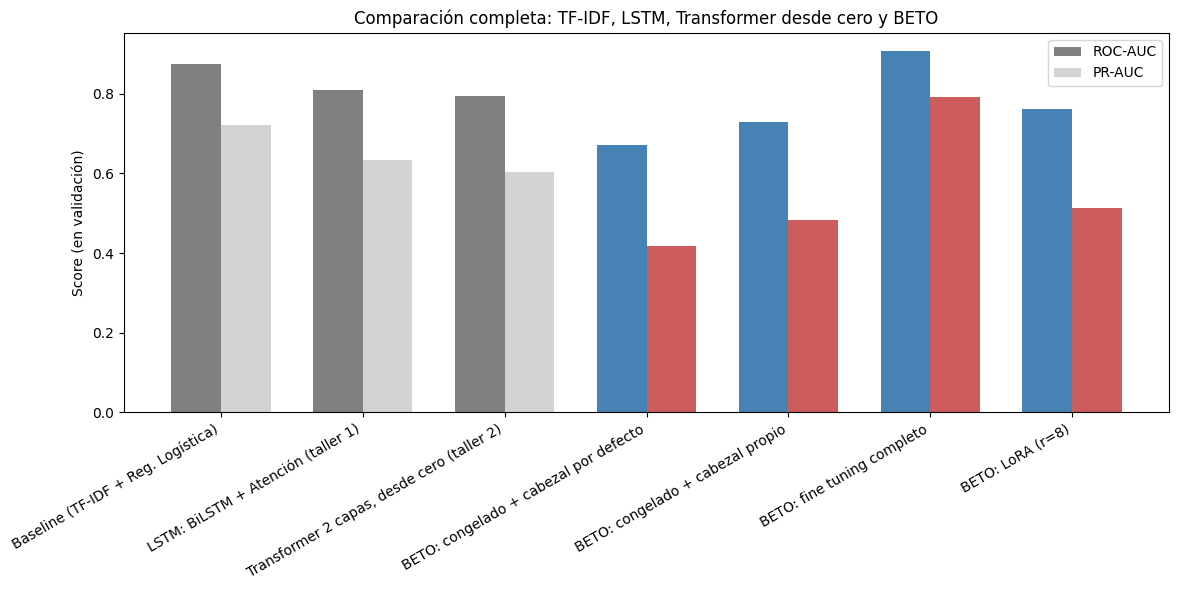

,ROC-AUC,PR-AUC
Baseline (TF-IDF + Reg. Logística),0.874000,0.721000
LSTM: BiLSTM + Atención (taller 1),0.810000,0.634000
"Transformer 2 capas, desde cero (taller 2)",0.793000,0.603000
BETO: congelado + cabezal por defecto,0.671602,0.416574
BETO: congelado + cabezal propio,0.727874,0.482286
BETO: fine tuning completo,0.907235,0.790507
BETO: LoRA (r=8),0.760412,0.513416


In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# resultados documentados en los talleres anteriores sobre este mismo dataset
historical_results = {
    'Baseline (TF-IDF + Reg. Logística)': {'roc_auc': 0.874, 'pr_auc': 0.721},
    'LSTM: BiLSTM + Atención (taller 1)': {'roc_auc': 0.810, 'pr_auc': 0.634},
    'Transformer 2 capas, desde cero (taller 2)': {'roc_auc': 0.793, 'pr_auc': 0.603},
}

# resultados obtenidos en este notebook
beto_results = {
    'BETO: congelado + cabezal por defecto': stage1_results,
    'BETO: congelado + cabezal propio': stage2_results,
    'BETO: fine tuning completo': stage3_results,
    'BETO: LoRA (r=8)': stage4_results,
}

all_names = list(historical_results.keys()) + list(beto_results.keys())
all_roc = [historical_results[n]['roc_auc'] for n in historical_results] + [beto_results[n]['roc_auc'] for n in beto_results]
all_pr = [historical_results[n]['pr_auc'] for n in historical_results] + [beto_results[n]['pr_auc'] for n in beto_results]

x = np.arange(len(all_names))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 6))
colors_roc = ['gray'] * len(historical_results) + ['steelblue'] * len(beto_results)
colors_pr = ['lightgray'] * len(historical_results) + ['indianred'] * len(beto_results)
ax.bar(x - width/2, all_roc, width, label='ROC-AUC', color=colors_roc)
ax.bar(x + width/2, all_pr, width, label='PR-AUC', color=colors_pr)
ax.set_xticks(x); ax.set_xticklabels(all_names, rotation=30, ha='right')
ax.set_ylabel('Score (en validación)')
ax.set_title('Comparación completa: TF-IDF, LSTM, Transformer desde cero y BETO')
ax.legend()
plt.tight_layout()
plt.show()

pd.DataFrame({'ROC-AUC': all_roc, 'PR-AUC': all_pr}, index=all_names)

### Lo que dice la comparación completa

Los siete enfoques, todos evaluados sobre el mismo dataset:

| Modelo | ROC-AUC | PR-AUC |
|---|---|---|
| Baseline (TF-IDF + Reg. Logística) | 0.874 | 0.721 |
| LSTM: BiLSTM + Atención (taller 1) | 0.810 | 0.634 |
| Transformer 2 capas, desde cero (taller 2) | 0.793 | 0.603 |
| BETO: congelado + cabezal por defecto | 0.672 | 0.417 |
| BETO: congelado + cabezal propio | 0.728 | 0.482 |
| **BETO: fine-tuning completo** | **0.907** | **0.791** |
| BETO: LoRA (r=8) | 0.760 | 0.513 |

Este resultado confirma la hipótesis central del planteamiento del problema. BETO con fine-tuning completo es el mejor de los siete enfoques. supera incluso al baseline de TF-IDF, que había resultado difícil de vencer en los dos talleres anteriores, tanto en ROC-AUC (0.907 frente a 0.874) como, de forma más marcada, en PR-AUC (0.791 frente a 0.721). 

Las dos etapas de BETO con backbone congelado (Etapas 1 y 2) quedan por debajo de todos los demás modelos. Contar con un modelo preentrenado no constituyó una ventaja: esta solo se materializó cuando se permitió a BETO reajustar sus propios pesos. El conocimiento adquirido durante el preentrenamiento solo se traduce en mejor desempeño en esta tarea cuando el modelo puede adaptarlo activamente durante el entrenamiento como se lo hace con el fine-tuning.

LoRA ofrece un desempeño intermedio: aunque entrena solo el 0.27% de los parámetros y supera al backbone congelado, su configuración conservadora ($r=8$) se queda muy por debajo del fine-tuning completo y del baseline de TF-IDF, demostrando ser menos efectiva de lo esperado para este problema específico.

El BETO con fine-tuning completo logra el mejor rendimiento global, destacando especialmente en la métrica clave PR-AUC (0.791) y en el F1 de la clase de odio (0.69), superando al modelo TF-IDF, pero a cambio de ser el enfoque computacionalmente más costoso de todos los evaluados.

## Selección de la mejor etapa, calibración del umbral y evaluación en test

In [31]:
stage_map = {
    'Congelado + cabezal por defecto': (trainer_stage1, stage1_results),
    'Congelado + cabezal propio': (trainer_stage2, stage2_results),
    'Fine tuning completo': (trainer_stage3, stage3_results),
    'LoRA (r=8)': (trainer_stage4, stage4_results),
}
best_stage_name = max(stage_map, key=lambda n: stage_map[n][1]['pr_auc'])
best_trainer, best_results = stage_map[best_stage_name]

print(f"Mejor etapa según PR-AUC en validación: {best_stage_name}")
print(f"  ROC-AUC(val)={best_results['roc_auc']:.3f}  PR-AUC(val)={best_results['pr_auc']:.3f}")

Mejor etapa según PR-AUC en validación: Fine tuning completo
  ROC-AUC(val)=0.907  PR-AUC(val)=0.791


In [32]:
from sklearn.metrics import f1_score
import numpy as np

val_probs = best_results['probs']
val_true = best_results['true']

best_threshold, best_f1 = 0.5, -1
for t in np.arange(0.10, 0.96, 0.05):
    preds_t = (val_probs >= t).astype(int)
    f1 = f1_score(val_true, preds_t, pos_label=1, zero_division=0)
    if f1 > best_f1:
        best_f1, best_threshold = f1, t

print(f"Mejor umbral en validación: {best_threshold:.2f} (F1={best_f1:.3f})")

Mejor umbral en validación: 0.50 (F1=0.706)


Modelo: BETO (Fine tuning completo)  |  Umbral: 0.50

              precision    recall  f1-score   support

     no odio       0.89      0.91      0.90      2237
        odio       0.72      0.67      0.69       749

    accuracy                           0.85      2986
   macro avg       0.80      0.79      0.80      2986
weighted avg       0.85      0.85      0.85      2986



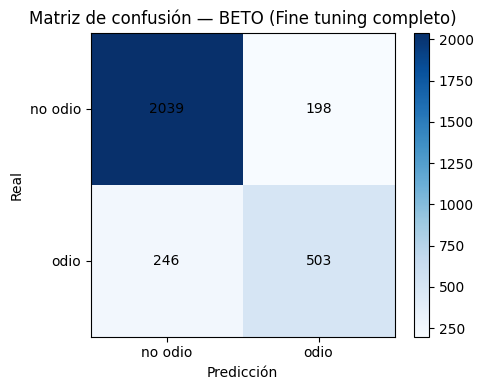

In [33]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

test_results = evaluate_probs(best_trainer, 'test')
test_probs, test_true = test_results['probs'], test_results['true']
predictions = (test_probs >= best_threshold).astype(int)

print(f"Modelo: BETO ({best_stage_name})  |  Umbral: {best_threshold:.2f}\n")
print(classification_report(test_true, predictions, target_names=['no odio', 'odio']))

cm = confusion_matrix(test_true, predictions)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_xticklabels(['no odio', 'odio'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['no odio', 'odio'])
ax.set_xlabel('Predicción'); ax.set_ylabel('Real')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='black')
plt.title(f'Matriz de confusión — BETO ({best_stage_name})')
plt.colorbar(im)
plt.tight_layout()
plt.show()

## Visualización de atención: BETO frente a nuestro Transformer desde cero

En el taller anterior visualizamos la atención de nuestro Transformer construido desde cero para el mismo tipo de frase. Replicamos el ejercicio aquí con BETO para comparar cualitativamente el patrón de atención de un modelo preentrenado frente a uno entrenado desde cero con datos limitados.

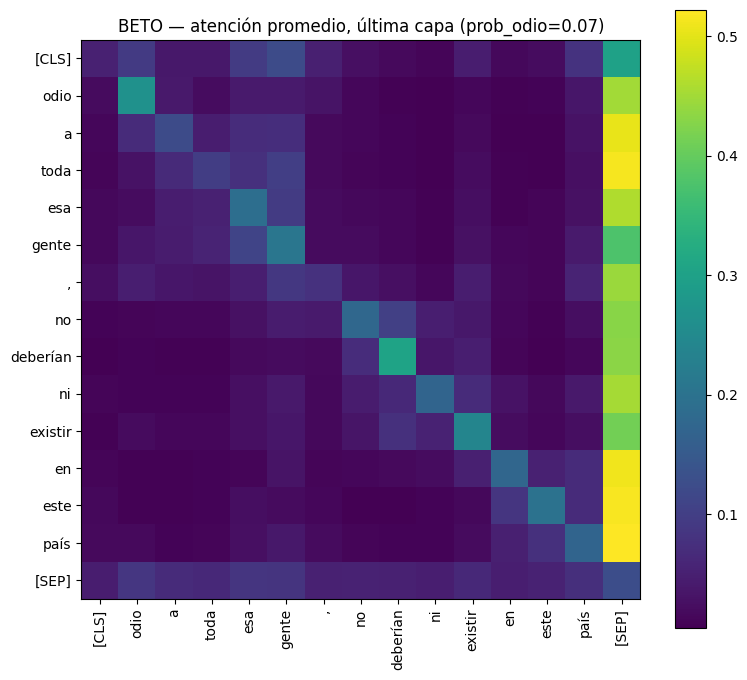

In [34]:
import matplotlib.pyplot as plt
import numpy as np

best_model = best_trainer.model
best_model.eval()

# A partir de ciertas versiones, transformers utiliza por defecto una
# implementación de atención optimizada (sdpa) que no expone los pesos
# de atención individuales, incluso si se solicita output_attentions=True;
# en ese caso, outputs.attentions se devuelve como una tupla vacía.
# Forzamos la implementación "eager" únicamente para esta inspección,
# sin necesidad de reentrenar: es un parámetro que se evalúa en cada
# pasada hacia adelante, no algo ligado a los pesos ya aprendidos.
best_model.config._attn_implementation = "eager"

texto_ejemplo = "odio a toda esa gente, no deberían ni existir en este país"
inputs = tokenizer(texto_ejemplo, max_length=MAX_LEN, truncation=True, padding='max_length', return_tensors='pt')
inputs = {k: v.to(best_model.device) for k, v in inputs.items()}

with torch.no_grad():
    outputs = best_model(**inputs, output_attentions=True)

# outputs.attentions es una tupla de 12 tensores (uno por capa), cada
# uno de forma (batch, num_heads, seq_len, seq_len). Promediamos la
# última capa entre sus 12 cabezas, siguiendo el mismo criterio aplicado
# a nuestro Transformer.
last_layer_attn = outputs.attentions[-1][0]          # (num_heads, seq_len, seq_len)
avg_attn = last_layer_attn.mean(dim=0).cpu().numpy()

n_real = int(inputs['attention_mask'][0].sum().item())
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])[:n_real]
probs = torch.softmax(outputs.logits, dim=1)[0].cpu().numpy()

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(avg_attn[:n_real, :n_real], cmap='viridis')
ax.set_xticks(range(len(tokens))); ax.set_xticklabels(tokens, rotation=90)
ax.set_yticks(range(len(tokens))); ax.set_yticklabels(tokens)
ax.set_title(f'BETO — atención promedio, última capa (prob_odio={probs[1]:.2f})')
plt.colorbar(im)
plt.tight_layout()
plt.show()

En nuestro Transformer desde cero, esta misma frase obtenía una probabilidad de odio consistentemente baja (entre 0.01 y 0.06) y un mapa de atención que se observaba disperso o concentrado en "gente". Si BETO produce una probabilidad sustancialmente mayor y/o un patrón de atención más definido para esta frase, constituye evidencia cualitativa adicional de la ventaja del preentrenamiento, más allá de las métricas ya evaluadas.

## Análisis de errores

In [35]:
import pandas as pd

test_texts = split_dataset['test']['text']

df = pd.DataFrame({
    'texto': test_texts,
    'real': test_true,
    'predicción': predictions,
    'prob_odio': test_probs,
})

false_negatives = df[(df['real'] == 1) & (df['predicción'] == 0)]
false_positives = df[(df['real'] == 0) & (df['predicción'] == 1)]

print(f"Falsos negativos: {len(false_negatives)}")
print(f"Falsos positivos: {len(false_positives)}")

false_negatives.sort_values('prob_odio', ascending=False).head(10)

Falsos negativos: 246
Falsos positivos: 198


,texto,real,predicción,prob_odio
716,@USER lo que yo no sé es qué quiere decir con ...,1,0,0.498867
661,ESAS COSAS Y OTRAS PUEDEN PASAR POR MANTENER A...,1,0,0.497707
2774,Las fronteras de #Espaa no son seguras. Los de...,1,0,0.496928
1384,Si ves un perro callejero y a un gay mata pri...,1,0,0.494590
2255,@USER Lo peor de esta dictadura sanitaria es q...,1,0,0.494158
527,@USER Es imposible que sean latinos. Si nunca ...,1,0,0.493877
2829,QUÉ ESPERAN PUTOS SUDACAS @USER CONTRATEN AL C...,1,0,0.491089
1716,"Por puto, por joto, porque así es México... lo...",1,0,0.489446
431,"@USER Ah pero primero estabas mame y mame ""est...",1,0,0.486182
754,@USER Lo que estoy diciendo que ese puesto de ...,1,0,0.484769


## Demo con frases manuales

Utilizamos las mismas frases del taller de Transformers, para permitir una comparación directa entre las predicciones de BETO y las del Transformer desde cero.

In [36]:
ejemplos_demo = [
    "Odio a toda esa gente, deberían desaparecer del país.",
    "No estoy de acuerdo con esa política, me parece injusta.",
    "Eres un imbécil, pero bueno, así es la política a veces.",
    "Qué día tan lindo para salir a caminar por el parque.",
    "Los inmigrantes están destruyendo este país, hay que echarlos a todos.",
]

def predecir(texto):
    inputs = tokenizer(texto, max_length=MAX_LEN, truncation=True, padding='max_length', return_tensors='pt')
    inputs = {k: v.to(best_model.device) for k, v in inputs.items()}
    best_model.eval()
    with torch.no_grad():
        logits = best_model(**inputs).logits
    prob_odio = torch.softmax(logits, dim=1)[0, 1].item()
    etiqueta = 'ODIO' if prob_odio >= best_threshold else 'no odio'
    return etiqueta, prob_odio

print(f"Modelo: BETO ({best_stage_name})\n")
for texto in ejemplos_demo:
    etiqueta, prob = predecir(texto)
    print(f"[{etiqueta:>8} | prob={prob:.2f}]  {texto}")

Modelo: BETO (Fine tuning completo)

[ no odio | prob=0.09]  Odio a toda esa gente, deberían desaparecer del país.
[ no odio | prob=0.09]  No estoy de acuerdo con esa política, me parece injusta.
[ no odio | prob=0.15]  Eres un imbécil, pero bueno, así es la política a veces.
[ no odio | prob=0.03]  Qué día tan lindo para salir a caminar por el parque.
[    ODIO | prob=0.81]  Los inmigrantes están destruyendo este país, hay que echarlos a todos.


## Conclusiones

1. Las tres etapas de BETO reprodujeron el patrón del notebook guía (cada etapa mejora sobre la anterior), con un salto pronunciado en la Etapa 3: el ROC-AUC pasó de 0.728 (congelado + cabezal propio) a 0.907 (fine-tuning completo). El backbone congelado, independientemente del cabezal utilizado, resulta insuficiente para este problema.
2. Incorporamos LoRA (r=8) como cuarta etapa, y su resultado matiza la narrativa anterior. Con apenas 0.27% de los parámetros de BETO entrenables, LoRA alcanzó ROC-AUC=0.760 y PR-AUC=0.513. Una mejora sobre el backbone congelado, pero considerablemente por debajo del fine-tuning completo. Esto sugiere que, para esta tarea, la magnitud de reajuste necesaria excede lo que una adaptación de rango tan bajo puede capturar con solo dos módulos objetivo por capa.
3. El fine-tuning completo de BETO es el mejor enfoque global (con un PR-AUC de 0.791 y un F1 de 0.69 para odio), superando claramente a los demás modelos y baselines, lo que demuestra que los modelos preentrenados solo son efectivos si se les permite reajustar sus parámetros y no se usan simplemente como extractores de características congelados.
4. A diferencia de la LSTM y el Transformer desde cero (que requirieron umbrales de decisión considerablemente por debajo de 0.5, indicio de probabilidades mal calibradas), BETO fine-tuned obtuvo su mejor F1 exactamente en el umbral por defecto (0.50). Un modelo que no requiere recalibración del umbral resulta, en la práctica, más directo de desplegar con confianza.
5. La frase "odio a toda esa gente, deberían desaparecer del país" continúa sin ser detectada correctamente incluso por el mejor modelo de los tres talleres (BETO fine-tuned la clasifica como "no odio", con prob=0.09). Es un resultado notable: un modelo objetivamente superior en las métricas agregadas puede seguir fallando en un caso individual que un modelo más débil (el Transformer desde cero) clasificó correctamente con alta confianza (0.96). Esto ilustra que las métricas agregadas no garantizan robustez ante casos individuales, y que este patrón específico ("odio a X" sin nombrar un grupo concreto ni emplear vocabulario ofensivo explícito) parece constituir un caso difícil para los tres enfoques.
6. Los falsos negativos de BETO se concentran en un rango muy estrecho alrededor del umbral (0.48–0.50), a diferencia de los de la LSTM y el Transformer, más dispersos y con probabilidades considerablemente menores a su umbral respectivo. Esto sugiere que BETO captura señal real incluso en los casos que clasifica incorrectamente: se trata de ejemplos genuinamente ambiguos en la frontera de decisión, no de casos que el modelo ignora por completo.